In [2]:
import pandas as pd

# Read one annotation file
df = pd.read_csv('/content/42845.csv')

print(df)
print("\nColumns:", df.columns.tolist())

                 4
0      15 69 40 96
1    10 173 42 203
2   74 212 100 243
3  233 197 256 226

Columns: ['4']


Image size: (256, 256)
Bounding boxes:
     0    1    2    3
0   15   69   40   96
1   10  173   42  203
2   74  212  100  243
3  233  197  256  226


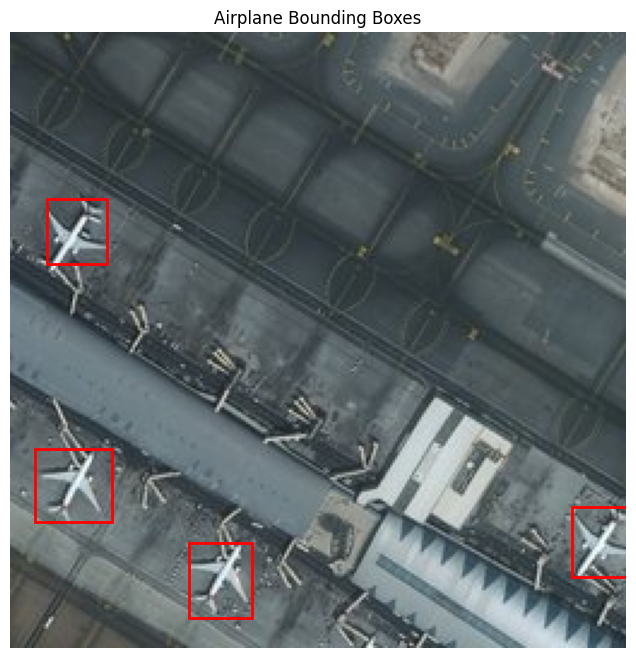

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# File paths
image_path = '/content/42845.jpg'
annotation_path = '/content/42845.csv'

# Load image
image = Image.open(image_path)

# Read annotation file
# First line = number of boxes
# Remaining lines = x_min y_min x_max y_max
df = pd.read_csv(
    annotation_path,
    sep=r'\s+',
    header=None,
    skiprows=1
)

print("Image size:", image.size)
print("Bounding boxes:")
print(df)

# Display image
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(image)

# Draw bounding boxes
for _, row in df.iterrows():

    x_min, y_min, x_max, y_max = row.iloc[:4]

    width = x_max - x_min
    height = y_max - y_min

    rectangle = patches.Rectangle(
        (x_min, y_min),
        width,
        height,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )

    ax.add_patch(rectangle)

plt.title("Airplane Bounding Boxes")
plt.axis("off")
plt.show()

In [4]:
import os

IMAGE_DIR = '/content'
ANNOTATION_DIR = '/content'

data = []
empty_annotations = []
missing_annotations = []

# Find all JPG images
image_files = [
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith('.jpg')
]

print("Number of images found:", len(image_files))

for image_file in image_files:

    # Corresponding CSV
    csv_file = os.path.splitext(image_file)[0] + '.csv'
    csv_path = os.path.join(ANNOTATION_DIR, csv_file)

    # Check whether annotation exists
    if not os.path.exists(csv_path):
        missing_annotations.append(image_file)
        continue

    try:
        # Read the annotation file as plain text
        with open(csv_path, 'r') as f:
            lines = [line.strip() for line in f if line.strip()]

        # Empty annotation file
        if len(lines) == 0:
            empty_annotations.append(image_file)
            continue

        # First line = number of airplanes
        num_boxes = int(lines[0])

        boxes = []

        # Remaining lines = bounding boxes
        for line in lines[1:]:
            values = line.split()

            if len(values) >= 4:
                x_min, y_min, x_max, y_max = map(float, values[:4])
                boxes.append([x_min, y_min, x_max, y_max])

        # Only keep images that have at least one bounding box
        if len(boxes) > 0:
            data.append({
                'image': image_file,
                'boxes': boxes
            })
        else:
            empty_annotations.append(image_file)

    except Exception as e:
        print("Problem with:", csv_file, "|", e)


print("\n-----------------------------")
print("Images found:", len(image_files))
print("Images with annotations:", len(data))
print("Empty/invalid annotations:", len(empty_annotations))
print("Missing annotations:", len(missing_annotations))
print("-----------------------------")

# Show first example
if len(data) > 0:
    print("\nFirst image:", data[0]['image'])
    print("Bounding boxes:", data[0]['boxes'])

Number of images found: 733

-----------------------------
Images found: 733
Images with annotations: 729
Empty/invalid annotations: 4
Missing annotations: 0
-----------------------------

First image: airplane_524.jpg
Bounding boxes: [[69.0, 133.0, 129.0, 202.0], [133.0, 73.0, 206.0, 143.0]]


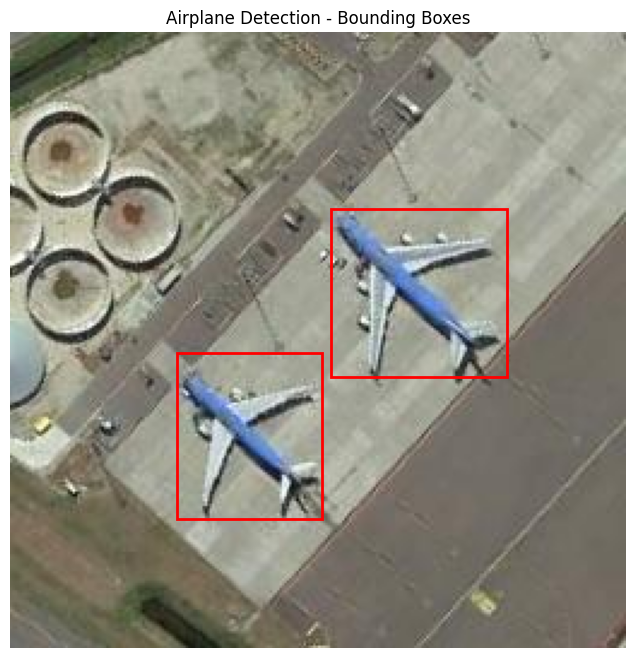

In [5]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os

item = data[0]

image_path = os.path.join(IMAGE_DIR, item['image'])
image = Image.open(image_path)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(image)

for box in item['boxes']:
    x_min, y_min, x_max, y_max = box

    rect = patches.Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )
    ax.add_patch(rect)

ax.set_title("Airplane Detection - Bounding Boxes")
ax.axis("off")
plt.show()

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import numpy as np

class AirplaneDataset(Dataset):
    def __init__(self, data, image_dir):
        self.data = data
        self.image_dir = image_dir

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # Load image
        image_path = os.path.join(self.image_dir, item['image'])
        image = Image.open(image_path).convert("RGB")

        # Convert image to tensor
        image = torch.tensor(np.array(image), dtype=torch.float32)
        image = image.permute(2, 0, 1) / 255.0

        # Bounding boxes
        boxes = torch.tensor(item['boxes'], dtype=torch.float32)

        # Label 1 = airplane
        labels = torch.ones((len(boxes),), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx])
        }

        return image, target


# Remove images with no bounding boxes
valid_data = [item for item in data if len(item['boxes']) > 0]

print("Total annotated images:", len(valid_data))

Total annotated images: 729


In [7]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(
    valid_data,
    test_size=0.2,
    random_state=42
)

print("Training images:", len(train_data))
print("Testing images:", len(test_data))

Training images: 583
Testing images: 146


In [8]:
train_dataset = AirplaneDataset(train_data, IMAGE_DIR)
test_dataset = AirplaneDataset(test_data, IMAGE_DIR)

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn
)

print("DataLoaders created successfully!")

DataLoaders created successfully!


In [9]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128


In [10]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# Select GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained Faster R-CNN
model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

# 2 classes: background + airplane
num_classes = 2

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

# Move model to GPU
model = model.to(device)

print("Model loaded successfully!")
print("Device:", device)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 189MB/s]


Model loaded successfully!
Device: cuda


In [11]:
import torch

# Training settings
num_epochs = 3

# Optimizer
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

# Learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=2,
    gamma=0.1
)

print("Training setup complete!")
print("Epochs:", num_epochs)
print("Device:", device)

Training setup complete!
Epochs: 3
Device: cuda


In [12]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [13]:
for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for images, targets in train_loader:
        images = [img.to(device) for img in images]

        targets = [
            {k: v.to(device) for k, v in t.items()}
            for t in targets
        ]

        optimizer.zero_grad()

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    lr_scheduler.step()

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [1/3], Loss: 0.3737
Epoch [2/3], Loss: 0.2671
Epoch [3/3], Loss: 0.2038


In [14]:
torch.save(model.state_dict(), "/content/faster_rcnn_airplane.pth")
print("Model saved successfully!")

Model saved successfully!


In [15]:
from google.colab import files

files.download('/content/faster_rcnn_airplane.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

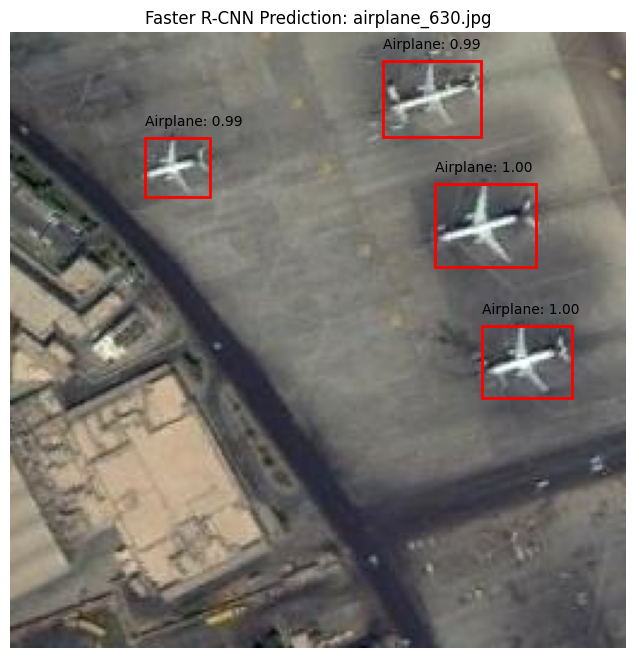

Airplanes detected: 4


In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch
import numpy as np
import os

# Select a test image
test_item = test_data[0]

image_name = test_item['image']
image_path = os.path.join(IMAGE_DIR, image_name)

# Load image
image = Image.open(image_path).convert("RGB")

# Convert image to tensor
image_tensor = torch.tensor(
    np.array(image),
    dtype=torch.float32
).permute(2, 0, 1) / 255.0

# Evaluation mode
model.eval()

with torch.no_grad():
    prediction = model([image_tensor.to(device)])

prediction = prediction[0]

boxes = prediction['boxes'].cpu()
scores = prediction['scores'].cpu()

# Display image
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(image)

threshold = 0.5
count = 0

for box, score in zip(boxes, scores):

    if score >= threshold:

        x_min, y_min, x_max, y_max = box

        rect = patches.Rectangle(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )

        ax.add_patch(rect)

        ax.text(
            x_min,
            y_min - 5,
            f"Airplane: {score:.2f}"
        )

        count += 1

plt.title(f"Faster R-CNN Prediction: {image_name}")
plt.axis("off")
plt.show()

print("Airplanes detected:", count)

In [17]:
from torchvision.ops import box_iou

# Ground-truth boxes
ground_truth = torch.tensor(
    test_item['boxes'],
    dtype=torch.float32
)

# Keep predictions above confidence threshold
threshold = 0.5
selected_boxes = boxes[scores >= threshold]

# Calculate IoU
if len(selected_boxes) > 0 and len(ground_truth) > 0:
    iou_matrix = box_iou(selected_boxes, ground_truth)

    # Best IoU for each predicted box
    best_iou, _ = iou_matrix.max(dim=1)

    print("Number of ground-truth airplanes:", len(ground_truth))
    print("Number of predicted airplanes:", len(selected_boxes))
    print("\nIoU values:")
    print(best_iou)

    print("\nAverage IoU:", best_iou.mean().item())
else:
    print("No boxes available for IoU calculation.")

Number of ground-truth airplanes: 4
Number of predicted airplanes: 4

IoU values:
tensor([0.8320, 0.8268, 0.8003, 0.8208])

Average IoU: 0.8199739456176758
